In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..', '..')))

import argparse
from pprint import pp
import torch
from torch import nn
from tqdm import tqdm
import numpy as np
import json
import os
from omegaconf import OmegaConf
from torch.utils.tensorboard import SummaryWriter

from lpn.utils import load_dataset, load_config
from lpn.utils import get_model
from lpn.utils import get_loss_hparams_and_lr, get_loss
from lpn.utils import trainer
from lpn.utils import utils
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
model_config_path = "./models/ne_lpn_64ch/s=0.1/model_config.json"
model_weight_path = "./models/ne_lpn_64ch/s=0.1/model.pt"
model_config = load_config(model_config_path)
model = get_model(model_config).to(device)
model.load_state_dict(torch.load(model_weight_path)["model_state_dict"])

init weights


<All keys matched successfully>

In [4]:
ne_dataset_config_path = "./configs/test_dataset.json"
ne_dataset_config = load_config(ne_dataset_config_path)
ne_dataset = load_dataset(ne_dataset_config, "test")
ne_dataloader = torch.utils.data.DataLoader(ne_dataset, batch_size=1, shuffle=False, num_workers=4)

dataset:  celeba


In [5]:
Lpn_config_path = "./models/lpn/s=0.1/model_config.json"
Lpn_weight_path = "./models/lpn/s=0.1/model.pt"

lpn_config = load_config(Lpn_config_path)
lpn = get_model(lpn_config).to(device)
lpn.load_state_dict(torch.load(Lpn_weight_path)["model_state_dict"])

init weights


<All keys matched successfully>

In [6]:
lpn_dataset_config_path = "./configs/test_dataset.json"
lpn_dataset_config = load_config(lpn_dataset_config_path)
lpn_test_dataset = load_dataset(lpn_dataset_config, "test")
lpn_test_data_loader = torch.utils.data.DataLoader(lpn_test_dataset, batch_size=1, shuffle=False, num_workers=4)

dataset:  celeba


In [7]:
def visualization_test(model, data_loader, noise, num_steps):

    for step, batch in enumerate(data_loader):
        if step >  num_steps:
            break

        clean_images = batch["image"].to(device)
        noise_mat = torch.randn_like(clean_images) * noise
        noisy_images = clean_images + noise_mat

        with torch.no_grad():
            denoised_images = model(noisy_images)

            mse_loss = nn.MSELoss()
            loss = mse_loss(denoised_images, clean_images)
            print(f"MSE Loss {step}: {loss}")

        clean_img = clean_images[0].cpu().detach().numpy().transpose(1, 2, 0)  # Convert from CHW to HWC
        noised_img = noisy_images[0].cpu().detach().numpy().transpose(1, 2, 0)
        denoised_img = denoised_images[0].cpu().detach().numpy().transpose(1, 2, 0)

        #plot clean, noised, and denoised images

        fig, ax = plt.subplots(1, 3)

        ax[0].imshow(clean_img)
        ax[0].set_title("Clean Image")
        ax[0].axis("off")

        ax[1].imshow(noised_img)
        ax[1].set_title("Noised Image")
        ax[1].axis("off")

        ax[2].imshow(denoised_img)
        ax[2].set_title("Denoised Image")
        ax[2].axis("off")
        plt.suptitle(f"Step {step}")
        plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


MSE Loss 0: 0.0016617423389106989


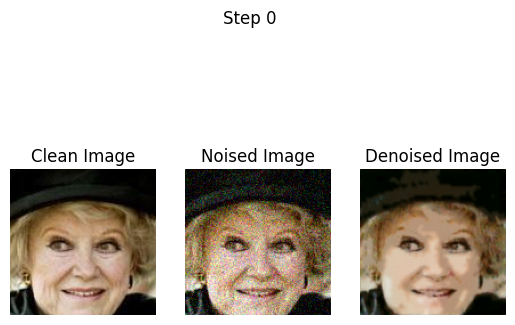

MSE Loss 1: 0.002295576734468341


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


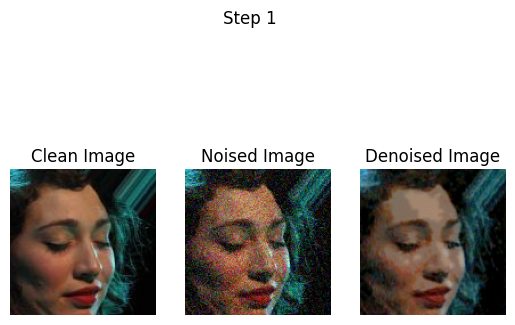

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


MSE Loss 2: 0.0018394698854535818


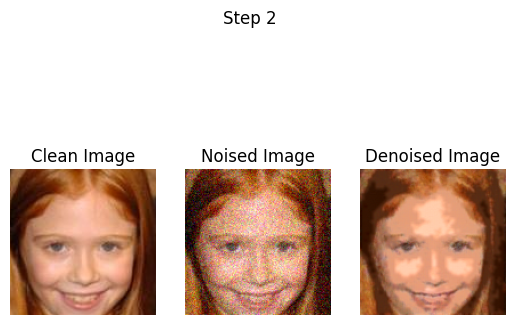

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


MSE Loss 3: 0.0017009367002174258


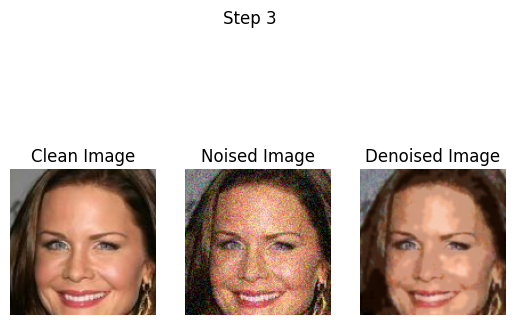

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


MSE Loss 4: 0.0011493139900267124


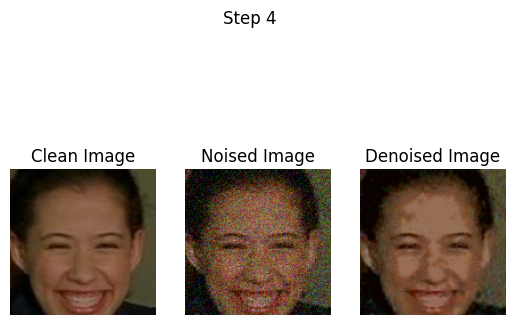

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


MSE Loss 5: 0.0024022264406085014


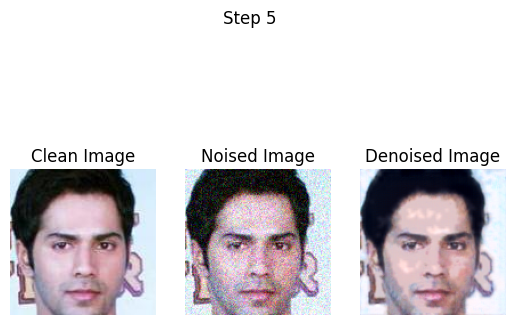

In [8]:
visualization_test(model, ne_dataloader, 0.1, 5)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


MSE Loss 0: 0.0006269394652917981


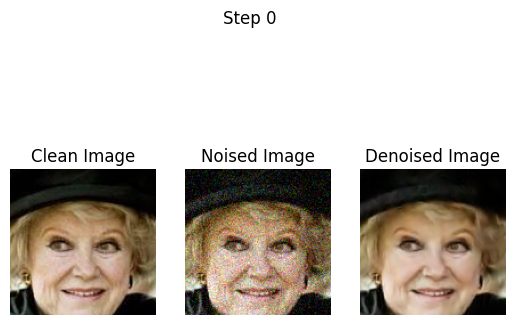

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


MSE Loss 1: 0.0007672123610973358


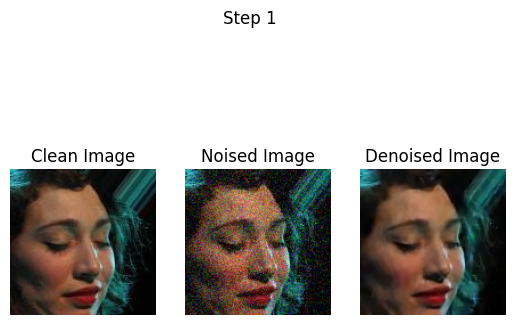

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


MSE Loss 2: 0.0005123160663060844


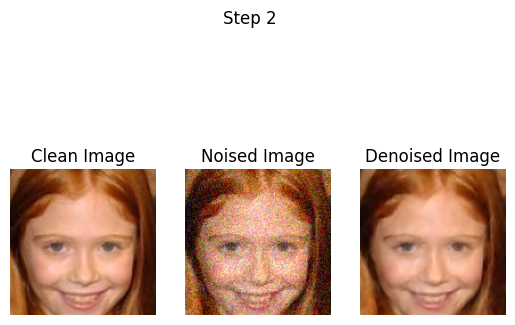

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


MSE Loss 3: 0.000635484408121556


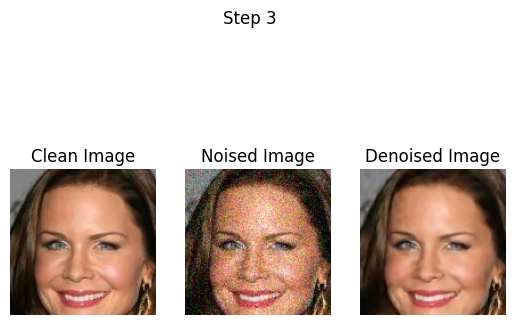

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


MSE Loss 4: 0.00035339020541869104


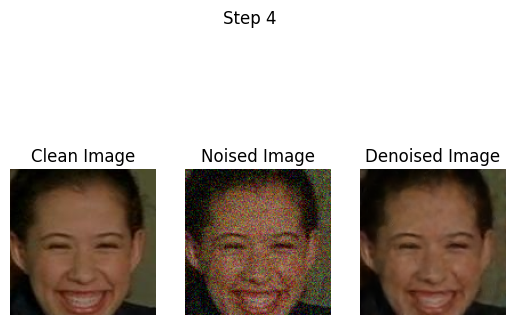

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


MSE Loss 5: 0.000639007892459631


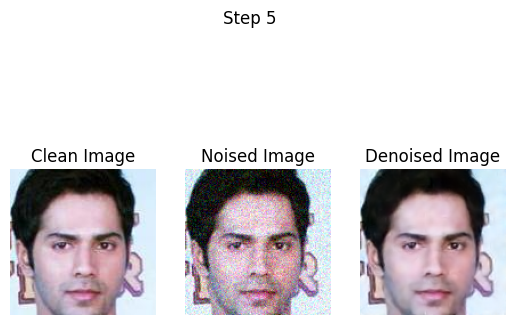

In [9]:
visualization_test(lpn, lpn_test_data_loader, 0.1, 5)